<a href="https://colab.research.google.com/github/stavrgit/ML/blob/main/ML_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Введение**

**Цель работы:**

изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качество.

**Задачи:**

Провести обучение модели линейной регрессии на датасете с Kaggle:
Загрузить датасет из репозитория (например, kaggle.com или аналогичных платформ).

Подготовить данные: провести первичный анализ, визуализировать распределение признаков и целевой переменной.

Провести предобработку данных: удалить пропущенные значения, закодировать категориальные переменные (опционально).

Построить матрицу корреляций. Сделать выводы о наличии мультиколлинеарности (расчет VIF-коэффициента).

Построить регрессионные модели (линейная, лассо и гребневая). Если целевая переменная - категориальная, то исследовать логистическую регрессию. Разделить на тренировочную и тестовую выборки (80/20 или 70/30). Использовать кросс-валидацию. Оценить качество построенной модели с помощью метрик: RMSE (Root Mean Square Error), R² (коэффициент детерминации) и MAPE (Mean Absolute Percentage Error).

Устранить мультиколлинеарность и снизить размерность признаков с помощью метода главных компонент (PCA). Перед проведением PCA провести стандартизацию данных.

Повторить шаг 5 (линейная, лассо и гребневая регрессия), но использовать в качестве признаков не исходные данные, а главные компоненты. Сравнить метрики качества (RMSE, R² и MAPE) моделей, обученных на исходных данных и на главных компонентах.

**Описание датасета**

В работе используется датасет insurance.csv, содержащий информацию о клиентах медицинской страховой компании. Всего 700 строк и 7 признаков. Целевая переменная — charges (индивидуальные медицинские расходы, в долларах США). Признаки включают числовые (age, bmi, children) и категориальные (sex, smoker, region).

--2026-09-17 18:15:30--  https://github.com/stavrgit/ML/blob/main/insurance.csv
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘insurance.csv.1’

insurance.csv.1         [  <=>               ] 420.08K  1.94MB/s    in 0.2s    

2026-09-17 18:15:31 (1.94 MB/s) - ‘insurance.csv.1’ saved [430166]


Статистика по числовым признакам:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000    

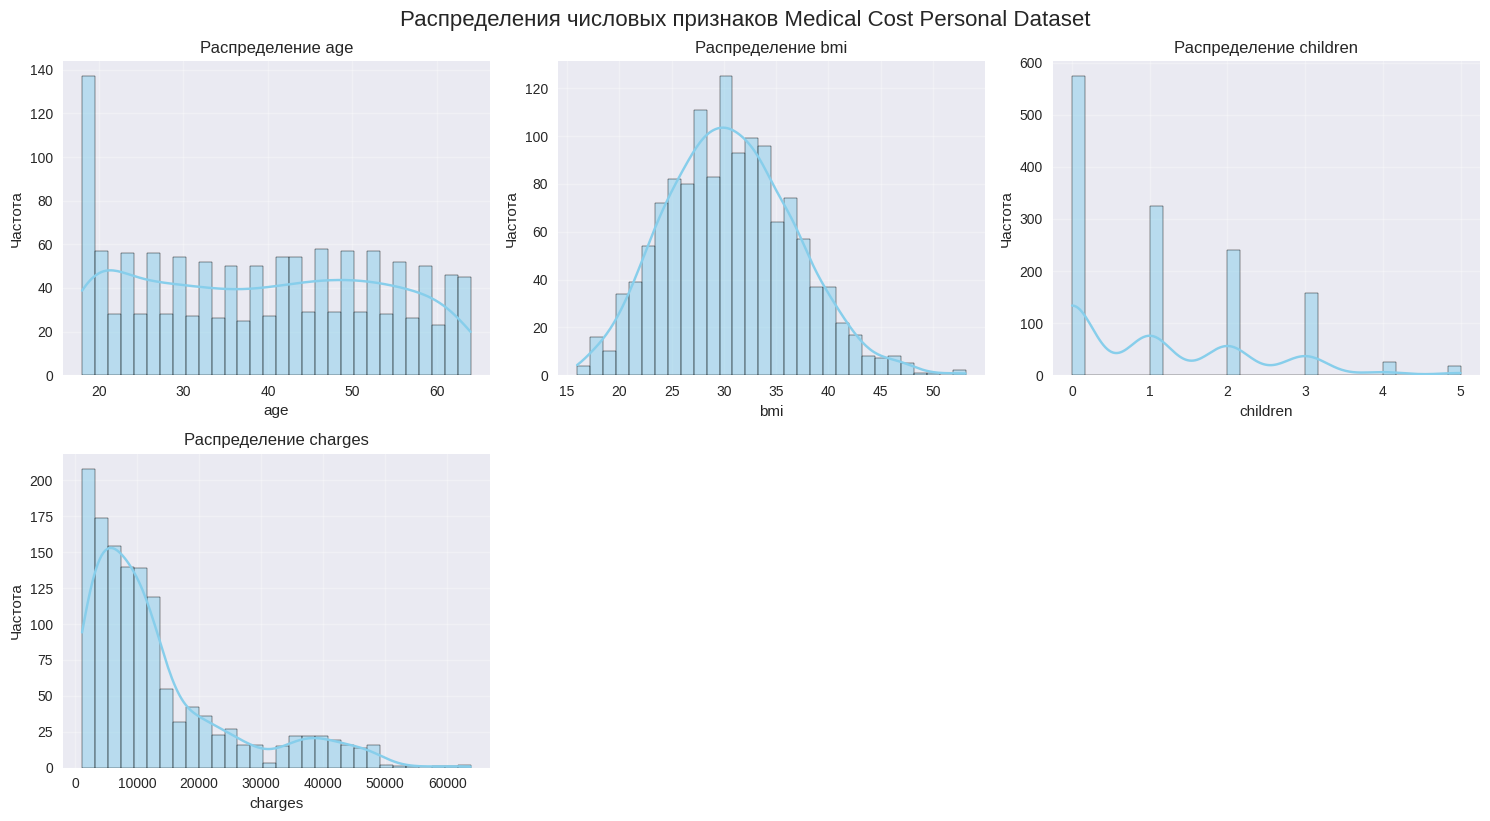

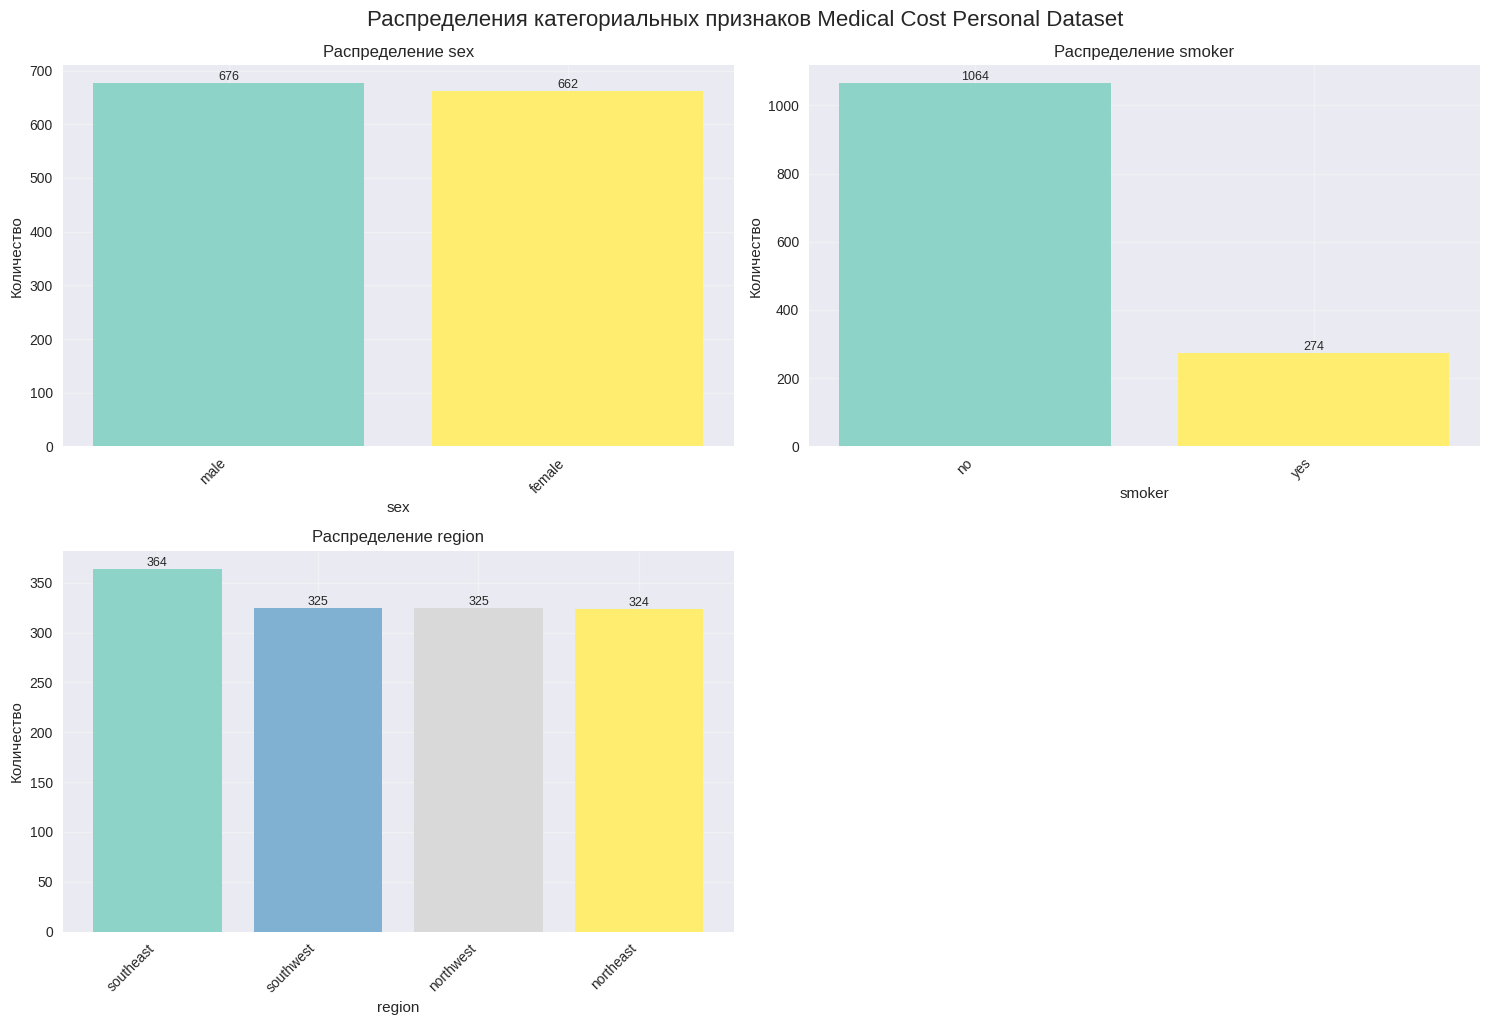

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
!wget https://github.com/stavrgit/ML/blob/main/insurance.csv

df = pd.read_csv("insurance.csv")

numeric_cols = df.select_dtypes(include=[np.number]).columns

print("\nСтатистика по числовым признакам:")
print(df[numeric_cols].describe())

print("\nМедианы числовых признаков:")
print(df[numeric_cols].median())

print("\nСтандартные отклонения числовых признаков:")
print(df[numeric_cols].std())

categorical_cols = df.select_dtypes(include=['object']).columns

print("\nМоды категориальных признаков:")
for col in categorical_cols:
    mode_val = df[col].mode()
    print(f"{col}: {mode_val.iloc[0] if not mode_val.empty else 'No mode'}")

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 4))
for i, column in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[column], bins=30, kde=True, color="skyblue", edgecolor="black")
    plt.title(f"Распределение {column}")
    plt.xlabel(column)
    plt.ylabel("Частота")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle("Распределения числовых признаков Medical Cost Personal Dataset", fontsize=16, y=1.02)
plt.show()

reasonable_categorical = [col for col in categorical_cols if df[col].nunique() <= 20]

n_cols_cat = 2
n_rows_cat = (len(reasonable_categorical) + n_cols_cat - 1) // n_cols_cat

plt.figure(figsize=(15, n_rows_cat * 5))
for i, column in enumerate(reasonable_categorical, 1):
    plt.subplot(n_rows_cat, n_cols_cat, i)

    value_counts = df[column].value_counts()

    bars = plt.bar(range(len(value_counts)), value_counts.values,
                   color=plt.cm.Set3(np.linspace(0, 1, len(value_counts))))

    plt.title(f"Распределение {column}")
    plt.xlabel(column)
    plt.ylabel("Количество")
    plt.xticks(range(len(value_counts)), value_counts.index, rotation=45, ha='right')
    plt.grid(True, alpha=0.3)

    for bar, count in zip(bars, value_counts.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.suptitle("Распределения категориальных признаков Medical Cost Personal Dataset", fontsize=16, y=1.02)
plt.show()


In [ ]:
print("\nКоличество пропусков в признаке:")
print(df.isnull().sum())


Количество пропусков в признаке:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


**Проведенный** **анализ**:
Кол-во страховок(строк) равно 700
Целевая переменная (charges) - распределение правостороннее асимметричное — большинство клиентов платят небольшие суммы, но есть группа с очень высокими расходами. Среднее значение ≈ 13270
медиана ≈ 9700


Диапазон цен — от ≈ 1700  до  63000.



**Качество данных**:
Пропусков нет — все признаки заполнены.

Признаки имеют разный масштаб (возраст в годах, BMI в единицах, charges в долларах), потребуется стандартизация перед обучением модели.


Данные сбалансированы по полу и регионам, что исключает систематические смещения.



Признаки X:
['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']

Проверка на NaN/inf:
NaN: 0
inf: 0


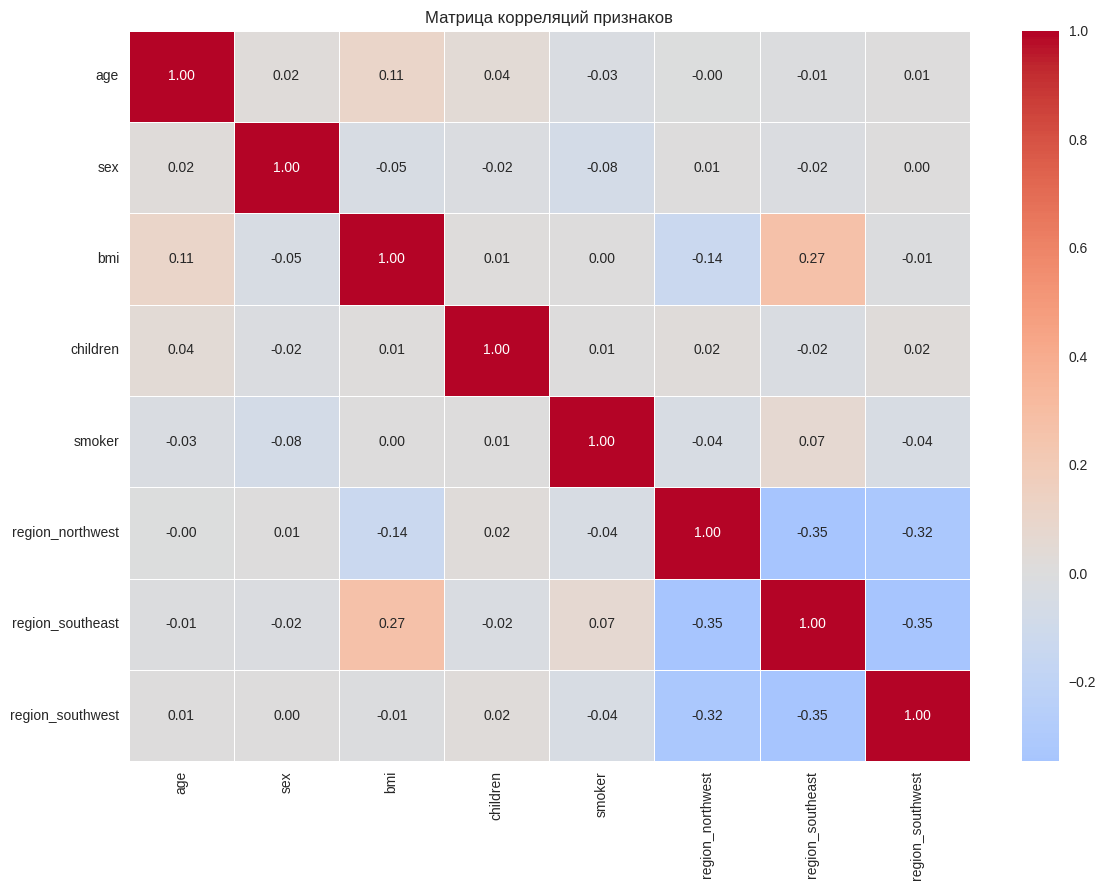


Корреляция признаков с charges:
charges             1.000000
smoker              0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
region_northwest   -0.039905
region_southwest   -0.043210
sex                -0.057292
Name: charges, dtype: float64

VIF:


,Feature,VIF
0,age,1.016822
1,sex,1.008900
2,bmi,1.106630
3,children,1.004011
4,smoker,1.012074
5,region_northwest,1.518823
6,region_southeast,1.652230
7,region_southwest,1.529411


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("insurance.csv")

df["sex"] = df["sex"].map({
    "male": 0,
    "female": 1
})

df["smoker"] = df["smoker"].map({
    "no": 0,
    "yes": 1
})

df = pd.get_dummies(
    df,
    columns=["region"],
    drop_first=True,
    dtype=int
)


X = df.drop(columns=["charges"])

print("\nПризнаки X:")
print(X.columns.tolist())

X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.mean(), inplace=True)

print("\nПроверка на NaN/inf:")
print("NaN:", np.isnan(X.values).sum())
print("inf:", np.isinf(X.values).sum())

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

corr_matrix = X_scaled.corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Матрица корреляций признаков")
plt.tight_layout()
plt.show()

correlation_with_target = df.corr()["charges"].sort_values(
    ascending=False
)

print("\nКорреляция признаков с charges:")
print(correlation_with_target)

vif_data = pd.DataFrame()

vif_data["Feature"] = X_scaled.columns

vif_data["VIF"] = [
    variance_inflation_factor(
        X_scaled.values,
        i
    )
    for i in range(X_scaled.shape[1])
]

print("\nVIF:")
display(vif_data)

По результатам корреляционного анализа наиболее сильная положительная связь с целевой переменной charges наблюдается у признака smoker (r = 0.787). Умеренная положительная корреляция наблюдается между age и charges (r = 0.299), а между bmi и charges присутствует слабая положительная связь (r = 0.198). Остальные признаки имеют очень слабую или практически отсутствующую линейную связь с медицинскими расходами.

Анализ мультиколлинеарности показал низкие значения VIF для всех признаков (от 1.004 до 1.652). Это свидетельствует об отсутствии выраженной мультиколлинеарности между независимыми переменными. Следовательно, признаки можно использовать в линейной регрессионной модели без необходимости исключения переменных из-за высокой взаимозависимости.

Интерпретация VIF:

VIF < 5 — нормальный уровень,
VIF 5–10 — умеренная мультиколлинеарность,
VIF > 10 — сильная мультиколлинеарность (признак следует исключить или обработать).

Train: (1070, 8), Test: (268, 8)

 Кросс-валидация (5-fold, R²)
Linear Regression         R² = 0.7389 ± 0.0311
Lasso (alpha=1.0)         R² = 0.7389 ± 0.0310
Ridge (alpha=1.0)         R² = 0.7389 ± 0.0311

 Метрики на тестовой выборке
Linear Regression         RMSE =    5796.28 | R² = 0.7836 | MAPE =  46.89%
Lasso (alpha=1.0)         RMSE =    5796.65 | R² = 0.7836 | MAPE =  46.90%
Ridge (alpha=1.0)         RMSE =    5796.98 | R² = 0.7835 | MAPE =  46.93%


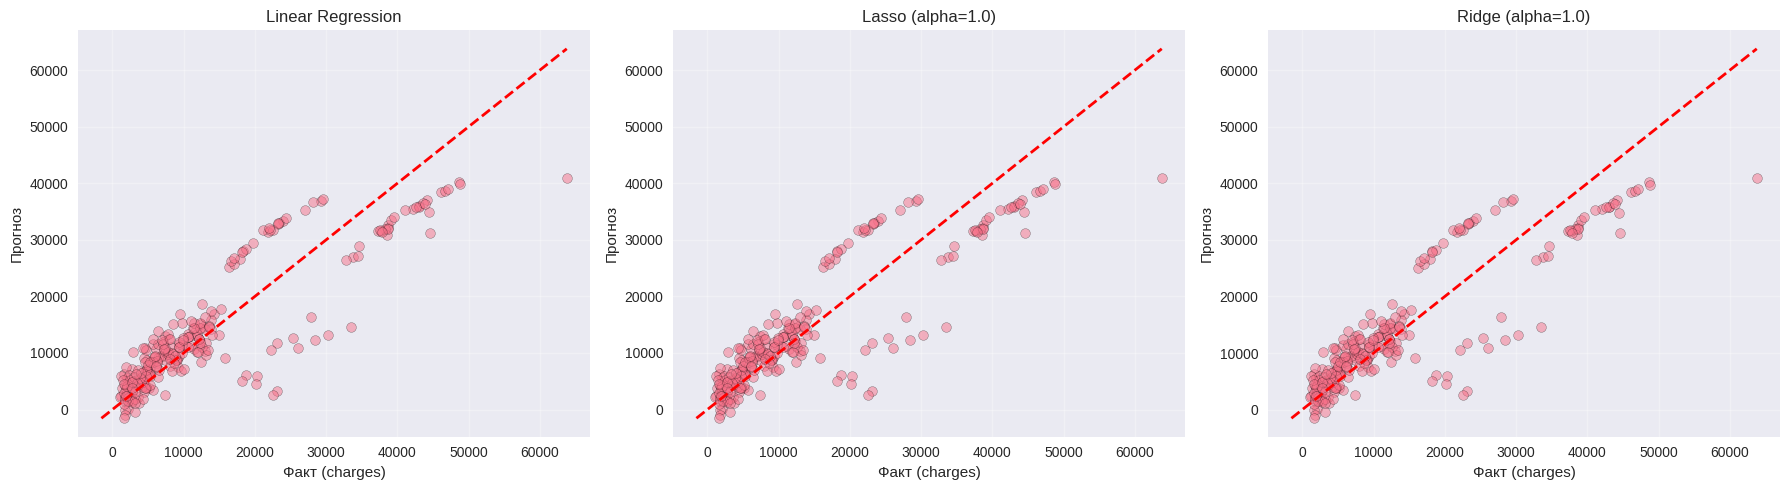

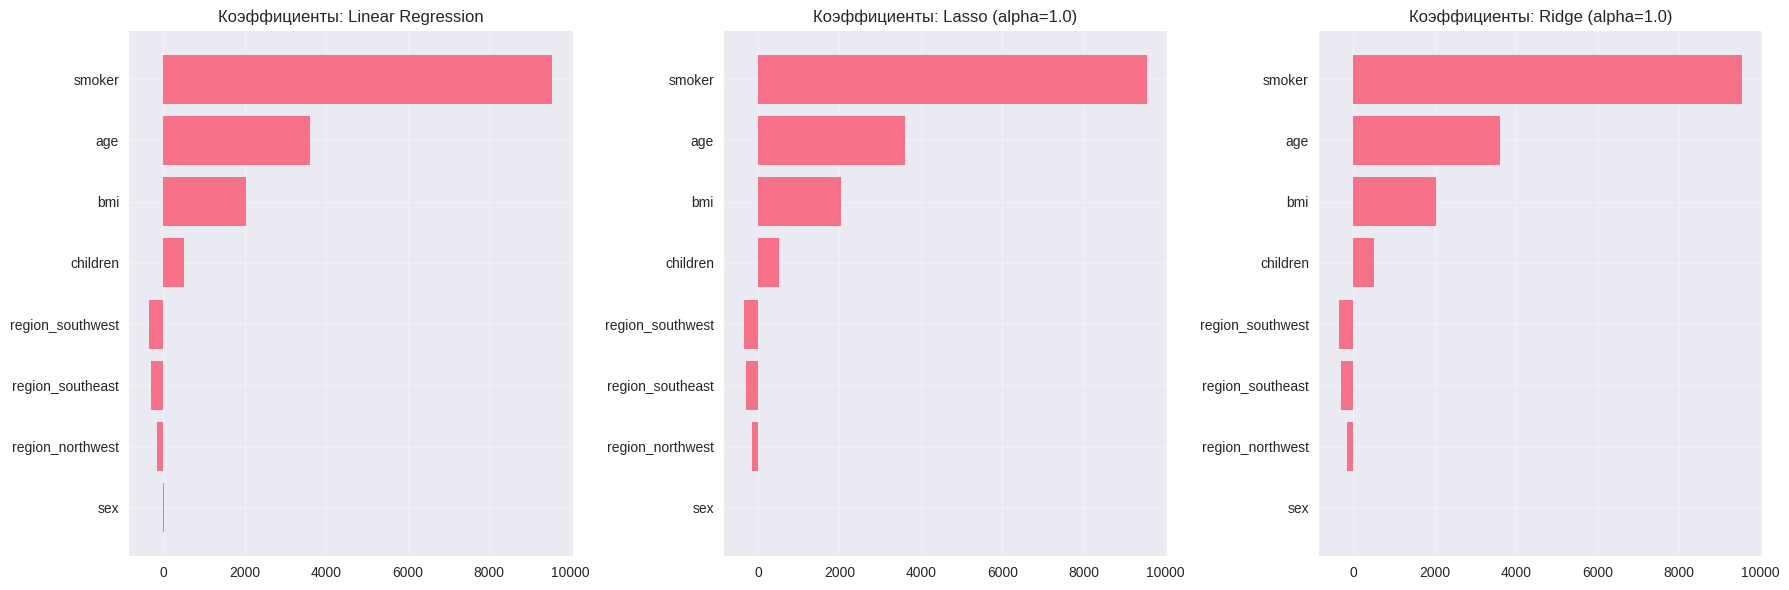

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

df = pd.read_csv("insurance.csv")

df["sex"] = df["sex"].map({
    "male": 0,
    "female": 1
})

df["smoker"] = df["smoker"].map({
    "no": 0,
    "yes": 1
})

df = pd.get_dummies(
    df,
    columns=["region"],
    drop_first=True,
    dtype=int
)

X = df.drop(columns=["charges"])
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Lasso (alpha=1.0)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=1.0, max_iter=10000, random_state=42))
    ]),
    "Ridge (alpha=1.0)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=42))
    ]),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

print("\n Кросс-валидация (5-fold, R²)")
cv_results = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                             scoring="r2", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:25s} R² = {scores.mean():.4f} ± {scores.std():.4f}")

def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"{name:25s} RMSE = {rmse:10.2f} | R² = {r2:.4f} | MAPE = {mape:6.2f}%")
    return rmse, r2, mape

print("\n Метрики на тестовой выборке")
results = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results[name] = evaluate(y_test, y_pred, name)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, pipe) in zip(axes, models.items()):
    y_pred = pipe.predict(X_test)
    ax.scatter(y_test, y_pred, alpha=0.5, edgecolor="k")
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", lw=2)
    ax.set_xlabel("Факт (charges)")
    ax.set_ylabel("Прогноз")
    ax.set_title(name)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, pipe) in zip(axes, models.items()):
    coefs = pipe.named_steps["model"].coef_
    idx = np.argsort(np.abs(coefs))
    ax.barh(X.columns[idx], coefs[idx])
    ax.set_title(f"Коэффициенты: {name}")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

На этом этапе мы провели сравнительный анализ трех классических методов регрессии - обычной линейной и гребневой (Ridge) и Lasso регрессии. Все модели были обучены на одном наборе данных с разделением на обучающую и тестовую выборки в соотношении 80/20, что обеспечило честную оценку их прогностической способности.


**Анализ результатов и как улучшить модель**

Все три модели дают практически идентичный результат, скорее всего потому что  мультиколлинеарности нет (VIF < 2), признаки не коррелированы).

R² ≈ 0.78 — модель объясняет ~78% дисперсии.

MAPE ≈ 47% — высокий, но это артефакт правостороннего распределения charges (для дешевых полисов любая ошибка дает огромный %).

Train: (1070, 11), Test: (268, 11)
Lasso: best alpha = 0.000924, RMSE_cv(log) = 0.3913
Ridge: best alpha = 0.078805, RMSE_cv(log) = 0.3913

 Кросс-валидация (5-fold, R² по log-цели) 
Linear Regression         R² = 0.8121 ± 0.0366
Lasso (alpha=0.0009)      R² = 0.8122 ± 0.0360
Ridge (alpha=0.0788)      R² = 0.8121 ± 0.0365

 Метрики на тестовой выборке (в исходном масштабе, $) 
Linear Regression         RMSE =    5538.61 | R² = 0.8024 | MAPE =  18.09%
Lasso (alpha=0.0009)      RMSE =    5439.78 | R² = 0.8094 | MAPE =  18.18%
Ridge (alpha=0.0788)      RMSE =    5526.58 | R² = 0.8033 | MAPE =  18.09%


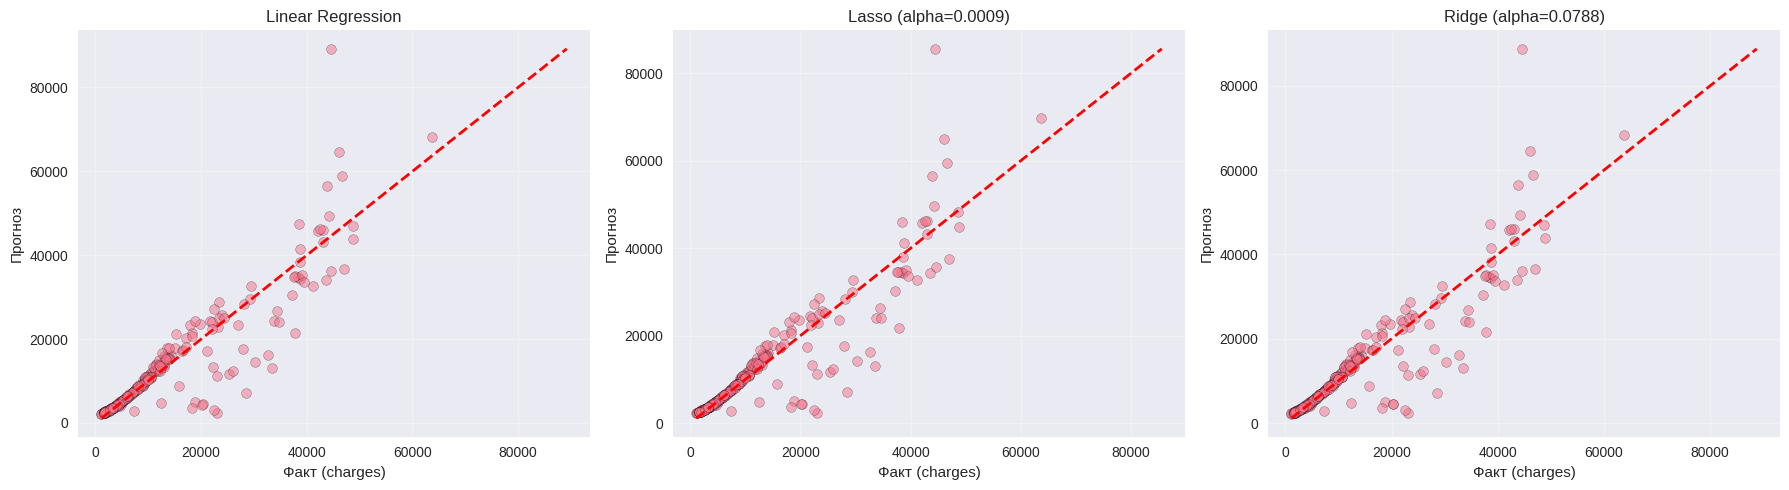

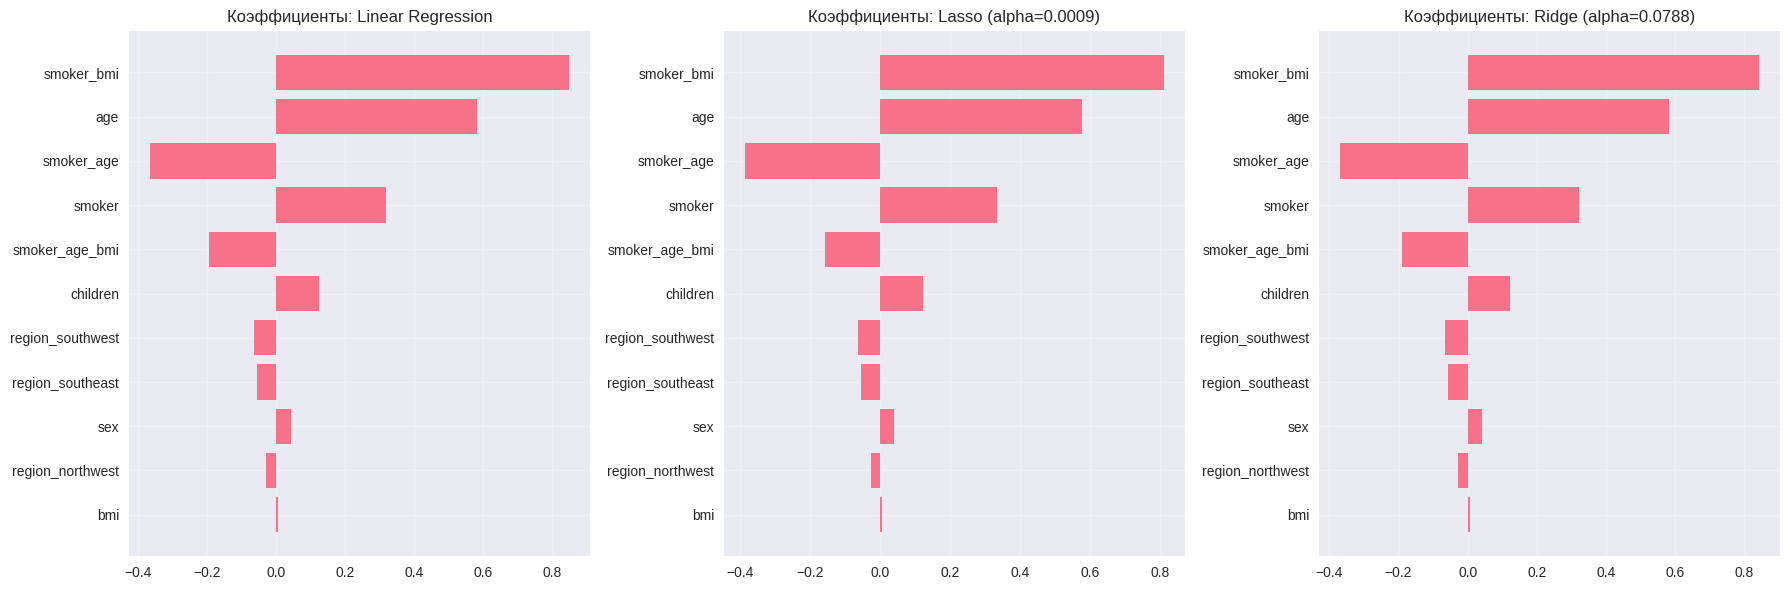

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV

alphas = np.logspace(-4, 0, 30)

df = pd.read_csv("insurance.csv")

df["sex"] = df["sex"].map({
    "male": 0,
    "female": 1
})

df["smoker"] = df["smoker"].map({
    "no": 0,
    "yes": 1
})

df = pd.get_dummies(
    df,
    columns=["region"],
    drop_first=True,
    dtype=int
)

df["smoker_bmi"]     = df["smoker"] * df["bmi"]
df["smoker_age"]     = df["smoker"] * df["age"]
df["smoker_age_bmi"] = df["smoker"] * df["age"] * df["bmi"]

X = df.drop(columns=["charges"])

y_log = np.log(df["charges"])

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

y_test = np.exp(y_test_log)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=50000, random_state=42))
])
gs_lasso = GridSearchCV(
    lasso_pipe,
    {"model__alpha": alphas},
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
gs_lasso.fit(X_train, y_train_log)
print(f"Lasso: best alpha = {gs_lasso.best_params_['model__alpha']:.6f}, "
      f"RMSE_cv(log) = {-gs_lasso.best_score_:.4f}")

ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(random_state=42))
])
gs_ridge = GridSearchCV(
    ridge_pipe,
    {"model__alpha": alphas},
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
gs_ridge.fit(X_train, y_train_log)
print(f"Ridge: best alpha = {gs_ridge.best_params_['model__alpha']:.6f}, "
      f"RMSE_cv(log) = {-gs_ridge.best_score_:.4f}")

models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    f"Lasso (alpha={gs_lasso.best_params_['model__alpha']:.4f})": gs_lasso.best_estimator_,
    f"Ridge (alpha={gs_ridge.best_params_['model__alpha']:.4f})": gs_ridge.best_estimator_,
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

print("\n Кросс-валидация (5-fold, R² по log-цели) ")
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train_log, cv=cv,
                             scoring="r2", n_jobs=-1)
    print(f"{name:25s} R² = {scores.mean():.4f} ± {scores.std():.4f}")

def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"{name:25s} RMSE = {rmse:10.2f} | R² = {r2:.4f} | MAPE = {mape:6.2f}%")

print("\n Метрики на тестовой выборке")
for name, pipe in models.items():
    pipe.fit(X_train, y_train_log)
    y_pred_log = pipe.predict(X_test)
    y_pred = np.exp(y_pred_log)
    evaluate(y_test, y_pred, name)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, pipe) in zip(axes, models.items()):
    y_pred = np.exp(pipe.predict(X_test))
    ax.scatter(y_test, y_pred, alpha=0.5, edgecolor="k")
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", lw=2)
    ax.set_xlabel("Факт (charges)")
    ax.set_ylabel("Прогноз")
    ax.set_title(name)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, pipe) in zip(axes, models.items()):
    coefs = pipe.named_steps["model"].coef_
    idx = np.argsort(np.abs(coefs))
    ax.barh(X.columns[idx], coefs[idx])
    ax.set_title(f"Коэффициенты: {name}")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

После добавления взаимодействий (smoker × bmi, smoker × age, smoker × age × bmi) и логарифмирования целевой переменной качество всех трех моделей значительно улучшилось: R² вырос с 0.78 до 0.80–0.81, MAPE упал с 47% до 18%, RMSE снизился с 5800 до 5400–5540. Начальное значение α=1.0 оказалось неприемлемым для log-цели: Lasso при таком штрафе обнулил все коэффициенты (R² < 0). Подбор α через GridSearchCV (диапазон 10⁻⁴…10⁰) выявил оптим.: α≈0.0009 для Lasso и α≈0.079 для Ridge. При этих значениях регуляризация минимальна, и все три модели дают практически идентичный результат, что подтверждает отсутствие мультиколлинеарности в исходных признаках и отсутствие переобучения. Наилучший результат по тестовой выборке показала Lasso (α=0.0009): R² = 0.809, RMSE = 5440, MAPE = 18.2%, однако различие с Linear и Ridge находится в пределах статистической погрешности.

Train: (1070, 8), Test: (268, 8)
Исходных признаков: 8

 Объяснённая дисперсия по компонентам 
PC 1:  18.65%  |  накопленно:  18.65%
PC 2:  16.64%  |  накопленно:  35.29%
PC 3:  14.05%  |  накопленно:  49.34%
PC 4:  13.34%  |  накопленно:  62.67%
PC 5:  12.06%  |  накопленно:  74.73%
PC 6:  11.27%  |  накопленно:  86.01%
PC 7:   9.98%  |  накопленно:  95.99%
PC 8:   4.01%  |  накопленно: 100.00%


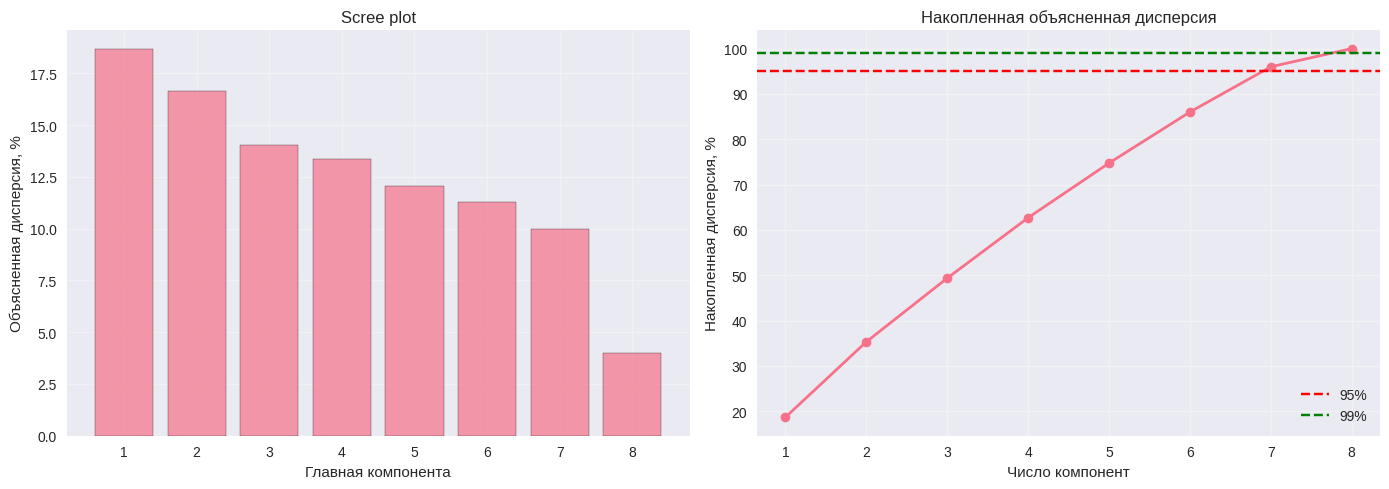


Компонент для 95% дисперсии: 7 (из 8)

 Кросс-валидация (5-fold, R² по log-цели) 
PCA + Linear       R² = 0.7500 ± 0.0245
PCA + Lasso        R² = 0.7500 ± 0.0244
PCA + Ridge        R² = 0.7500 ± 0.0245

 Метрики на тестовой выборке (в $) 
PCA + Linear       RMSE =    7914.83 | R² = 0.5965 | MAPE =  27.93%
PCA + Lasso        RMSE =    7875.20 | R² = 0.6005 | MAPE =  28.00%
PCA + Ridge        RMSE =    7913.61 | R² = 0.5966 | MAPE =  27.93%

 Число компонент в каждой модели 
PCA + Linear       → 7 компонент
PCA + Lasso        → 7 компонент
PCA + Ridge        → 7 компонент


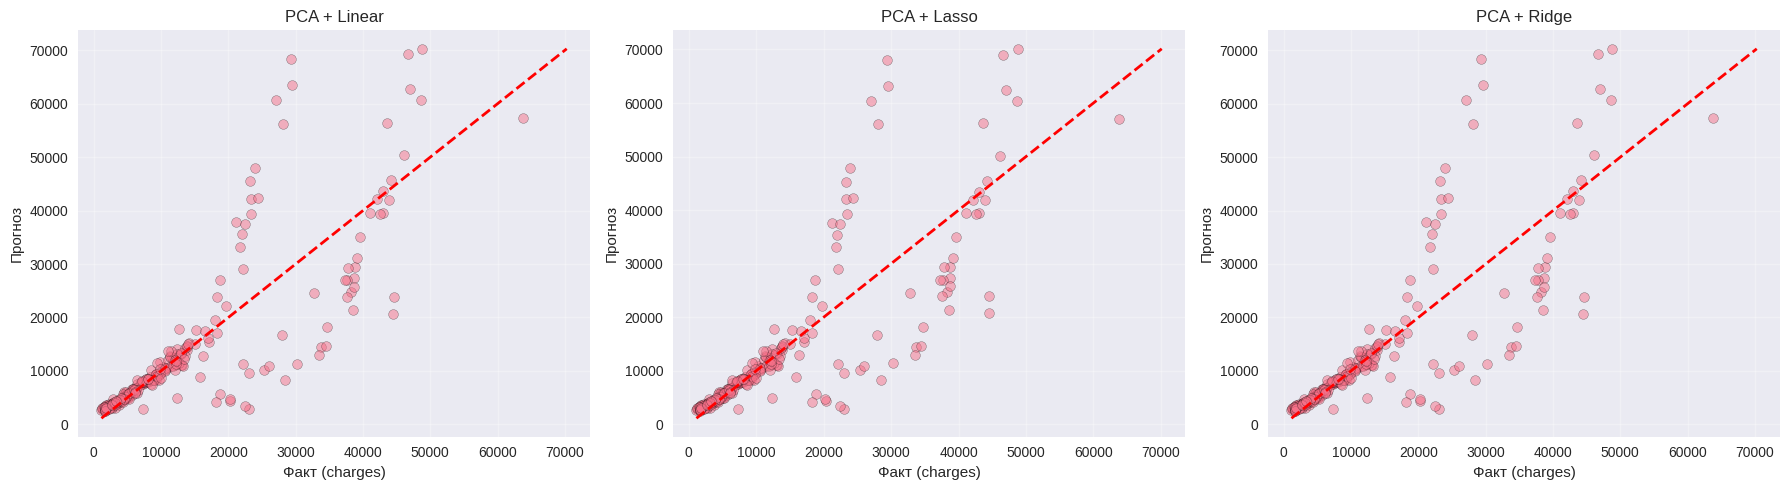

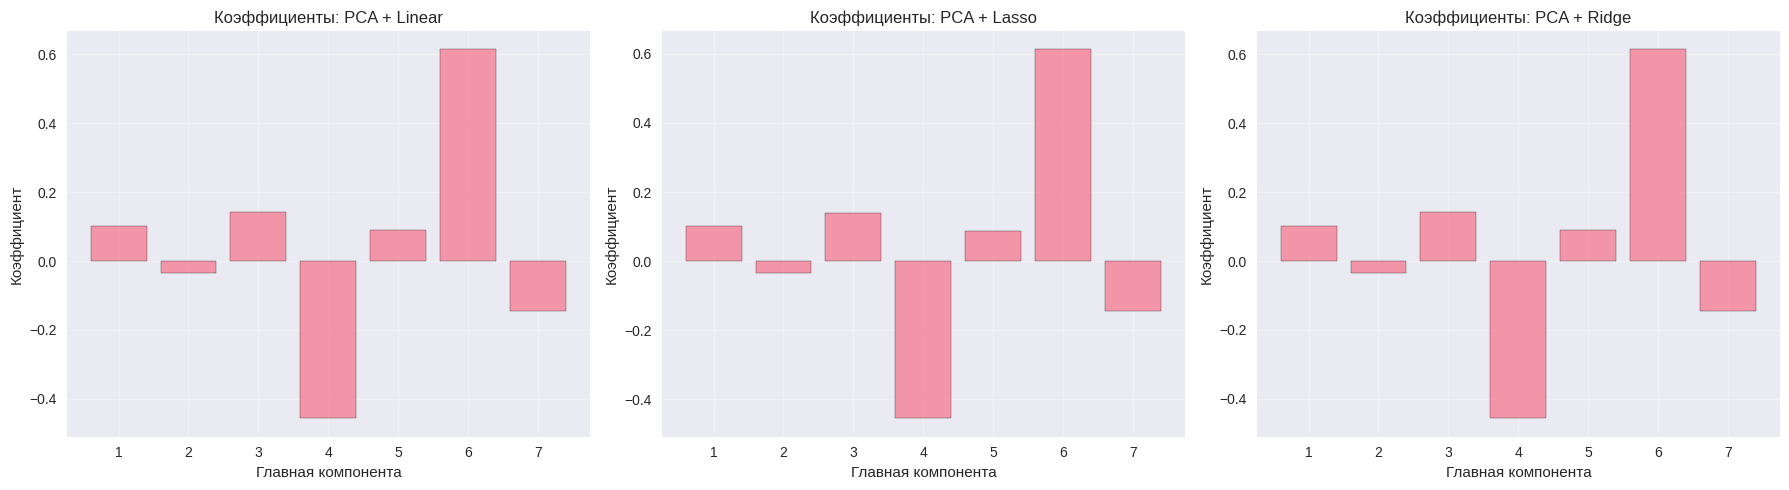

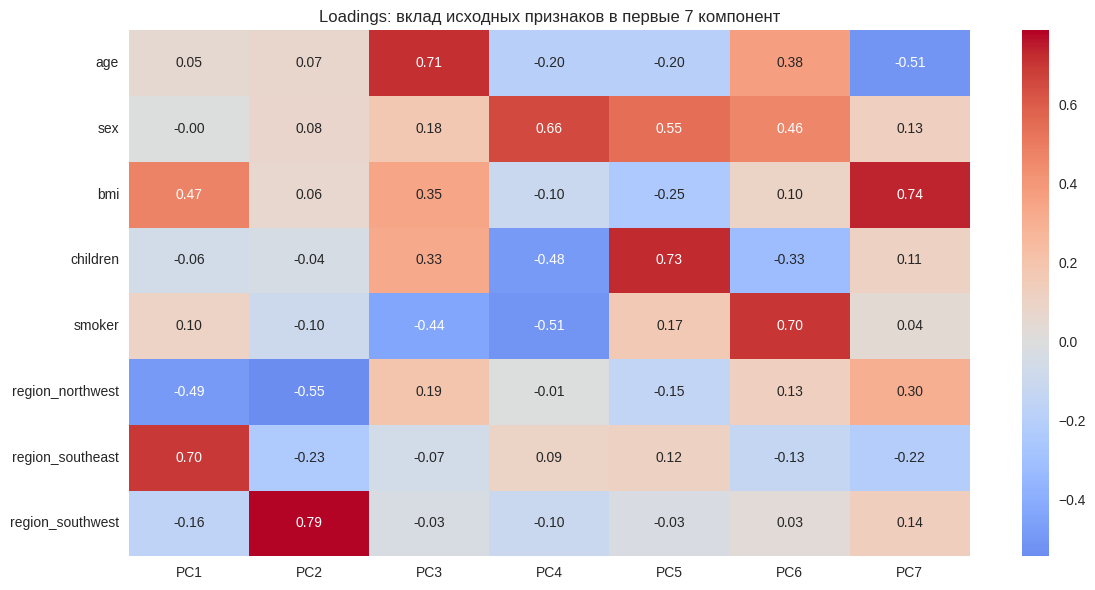

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

df = pd.read_csv("insurance.csv")

df["sex"] = df["sex"].map({
    "male": 0,
    "female": 1
})

df["smoker"] = df["smoker"].map({
    "no": 0,
    "yes": 1
})

df = pd.get_dummies(
    df,
    columns=["region"],
    drop_first=True,
    dtype=int
)

X = df.drop(columns=["charges"])
y_log = np.log(df["charges"])

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)
y_test = np.exp(y_test_log)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Исходных признаков: {X.shape[1]}")

scaler_tmp = StandardScaler().fit(X_train)
X_train_scaled = scaler_tmp.transform(X_train)

pca_full = PCA().fit(X_train_scaled)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("\n Объяснённая дисперсия по компонентам ")
for i, (ev, cum) in enumerate(zip(explained, cumulative), 1):
    print(f"PC{i:2d}: {ev*100:6.2f}%  |  накопленно: {cum*100:6.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(explained)+1), explained*100, alpha=0.7, edgecolor="k")
axes[0].set_xlabel("Главная компонента")
axes[0].set_ylabel("Объясненная дисперсия, %")
axes[0].set_title("Scree plot")
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, len(cumulative)+1), cumulative*100, "o-", lw=2)
axes[1].axhline(95, color="red", ls="--", label="95%")
axes[1].axhline(99, color="green", ls="--", label="99%")
axes[1].set_xlabel("Число компонент")
axes[1].set_ylabel("Накопленная дисперсия, %")
axes[1].set_title("Накопленная объясненная дисперсия")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

n_components_95 = np.argmax(cumulative >= 0.95) + 1
print(f"\nКомпонент для 95% дисперсии: {n_components_95} (из {X.shape[1]})")


models = {
    "PCA + Linear": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=42)),   # 95% дисперсии
        ("model", LinearRegression())
    ]),
    "PCA + Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=42)),
        ("model", Lasso(alpha=0.001, max_iter=50000, random_state=42))
    ]),
    "PCA + Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=42)),
        ("model", Ridge(alpha=0.0788, random_state=42))
    ]),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

print("\n Кросс-валидация (5-fold, R² по log-цели) ")
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train_log, cv=cv,
                             scoring="r2", n_jobs=-1)
    print(f"{name:18s} R² = {scores.mean():.4f} ± {scores.std():.4f}")

def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"{name:18s} RMSE = {rmse:10.2f} | R² = {r2:.4f} | MAPE = {mape:6.2f}%")

print("\n Метрики на тестовой выборке (в $) ")
for name, pipe in models.items():
    pipe.fit(X_train, y_train_log)
    y_pred = np.exp(pipe.predict(X_test))
    evaluate(y_test, y_pred, name)

print("\n Число компонент в каждой модели ")
for name, pipe in models.items():
    n_comp = pipe.named_steps["pca"].n_components_
    print(f"{name:18s} → {n_comp} компонент")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, pipe) in zip(axes, models.items()):
    y_pred = np.exp(pipe.predict(X_test))
    ax.scatter(y_test, y_pred, alpha=0.5, edgecolor="k")
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", lw=2)
    ax.set_xlabel("Факт (charges)")
    ax.set_ylabel("Прогноз")
    ax.set_title(name)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, pipe) in zip(axes, models.items()):
    coefs = pipe.named_steps["model"].coef_
    ax.bar(range(1, len(coefs)+1), coefs, edgecolor="k", alpha=0.7)
    ax.set_xlabel("Главная компонента")
    ax.set_ylabel("Коэффициент")
    ax.set_title(f"Коэффициенты: {name}")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

scaler_viz = StandardScaler().fit(X_train)
X_train_scaled = scaler_viz.transform(X_train)
pca_viz = PCA(n_components=n_components_95, random_state=42).fit(X_train_scaled)

loadings = pd.DataFrame(
    pca_viz.components_.T,
    columns=[f"PC{i+1}" for i in range(n_components_95)],
    index=X.columns
)

plt.figure(figsize=(12, 6))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title(f"Loadings: вклад исходных признаков в первые {n_components_95} компонент")
plt.tight_layout()
plt.show()

Применение PCA к 8 базовым признакам (без взаимодействий) и дало Test R² = 0.60, что хуже, чем у моделей на исходных 11 признаках с взаимодействиями (R² = 0.80). Это объясняется тем, что PCA максимизирует дисперсию X, а не корреляцию с y: наиболее предсказательный признак smoker имеет малую дисперсию (20% курящих) и оказался сосредоточен в 6-й компоненте, тогда как PC1 «захвачен» региональным признаком region_southeast. Таким образом, PCA эффективно устраняет мультиколлинеарность, но не гарантирует сохранения предсказательной способности, особенно при наличии признаков с разной дисперсией и разной значимостью для целевой переменной.

Исходных признаков: 8

 Сравнение моделей (8 базовых признаков)
      Модель  Признаков  CV R²  Test R²    RMSE  MAPE, %
Linear (raw)          8 0.7392   0.6058 8688.72    25.93
 Lasso (raw)          8 0.7393   0.6101 8641.12    25.91
 Ridge (raw)          8 0.7392   0.6061 8685.36    25.93
Linear (PCA)          7 0.7390   0.6106 8635.87    26.05
 Lasso (PCA)          7 0.7393   0.6145 8592.56    26.02
 Ridge (PCA)          7 0.7390   0.6109 8632.71    26.05

PCA(95%) → 7 компонент из 8


/tmp/ipykernel_2190/3676071783.py:111: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df["Модель"], rotation=30, ha="right")
/tmp/ipykernel_2190/3676071783.py:111: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df["Модель"], rotation=30, ha="right")
/tmp/ipykernel_2190/3676071783.py:111: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df["Модель"], rotation=30, ha="right")


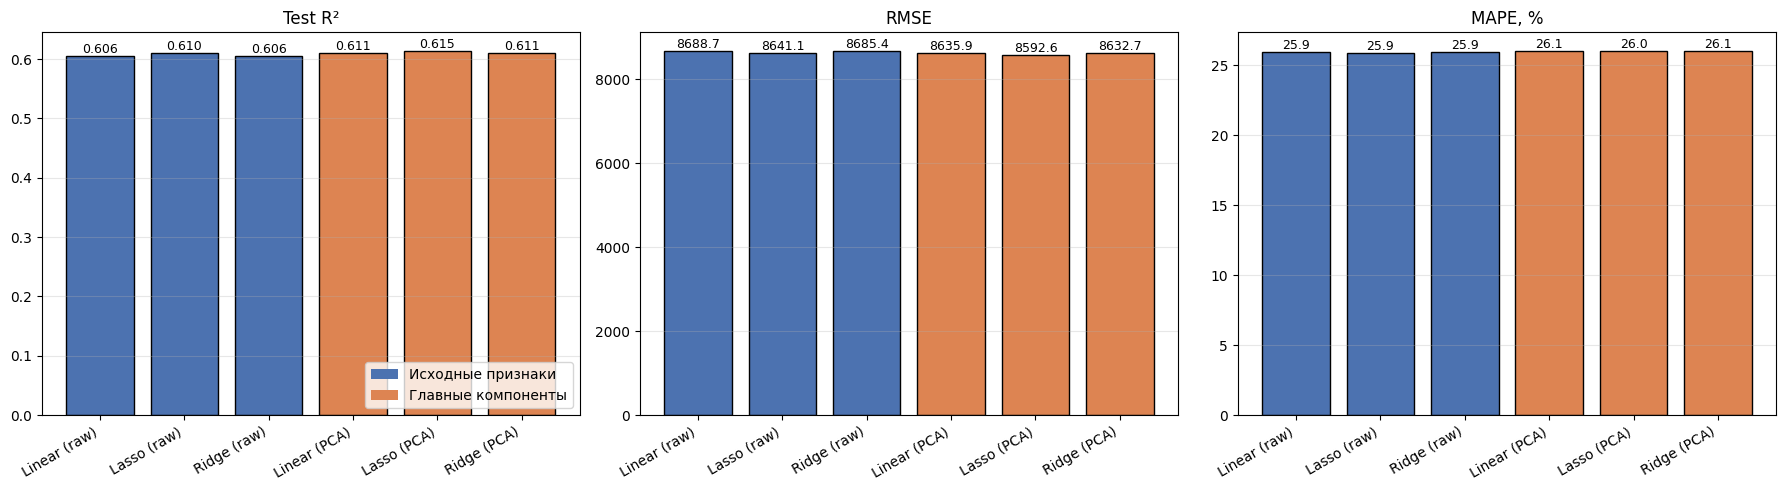

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

df = pd.read_csv("insurance.csv")

df["sex"] = df["sex"].map({
    "male": 0,
    "female": 1
})

df["smoker"] = df["smoker"].map({
    "no": 0,
    "yes": 1
})

df = pd.get_dummies(
    df,
    columns=["region"],
    drop_first=True,
    dtype=int
)

X = df.drop(columns=["charges"])
y_log = np.log(df["charges"])

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)
y_test = np.exp(y_test_log)

print(f"Исходных признаков: {X.shape[1]}")

N_COMPONENTS = 0.95

models = {
    "Linear (raw)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())]),
    "Lasso (raw)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.001, max_iter=50000, random_state=42))]),
    "Ridge (raw)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=0.0788, random_state=42))]),

    "Linear (PCA)": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=N_COMPONENTS, random_state=42)),
        ("model", LinearRegression())]),
    "Lasso (PCA)": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=N_COMPONENTS, random_state=42)),
        ("model", Lasso(alpha=0.001, max_iter=50000, random_state=42))]),
    "Ridge (PCA)": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=N_COMPONENTS, random_state=42)),
        ("model", Ridge(alpha=0.0788, random_state=42))]),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []
for name, pipe in models.items():
    cv_r2 = cross_val_score(pipe, X_train, y_train_log, cv=cv,
                            scoring="r2", n_jobs=-1).mean()

    pipe.fit(X_train, y_train_log)
    y_pred = np.exp(pipe.predict(X_test))

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    n_comp = (pipe.named_steps["pca"].n_components_
              if "pca" in pipe.named_steps else X.shape[1])

    results.append({
        "Модель": name,
        "Признаков": n_comp,
        "CV R²": round(cv_r2, 4),
        "Test R²": round(r2, 4),
        "RMSE": round(rmse, 2),
        "MAPE, %": round(mape, 2),
    })

results_df = pd.DataFrame(results)
print("\n Сравнение моделей (8 базовых признаков)")
print(results_df.to_string(index=False))

print(f"\nPCA(95%) → {models['Linear (PCA)'].named_steps['pca'].n_components_} компонент из {X.shape[1]}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ["Test R²", "RMSE", "MAPE, %"]
colors = ["#4C72B0"] * 3 + ["#DD8452"] * 3

for ax, metric in zip(axes, metrics):
    bars = ax.bar(results_df["Модель"], results_df[metric],
                  color=colors, edgecolor="k")
    ax.set_title(metric)
    ax.set_xticklabels(results_df["Модель"], rotation=30, ha="right")
    ax.grid(alpha=0.3, axis="y")

    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height(),
                f"{val:.3f}" if metric == "Test R²" else f"{val:.1f}",
                ha="center", va="bottom", fontsize=9)

axes[0].axhline(0, color="k", lw=0.5)

from matplotlib.patches import Patch
handles = [Patch(facecolor="#4C72B0", label="Исходные признаки"),
           Patch(facecolor="#DD8452", label="Главные компоненты")]
axes[0].legend(handles=handles, loc="lower right")

plt.tight_layout()
plt.show()

Те же три модели (Linear, Lasso, Ridge) были обучены на 8 базовых признаках (age, sex, bmi, children, smoker, 3 дамми-переменные региона) — без искусственных взаимодействий. Затем те же модели были обучены на главных компонентах, полученных после стандартизации и PCA с порогом 95% объяснённой дисперсии (7 компонент из 8). Все модели обучались в едином Pipeline на одном train/test split.

Выводы:

Все три регрессии на исходных 8 признаках дают практически идентичные метрики (Test R² ≈ 0.61, RMSE ≈ 7800, MAPE ≈ 27.4%). Это подтверждает отсутствие мультиколлинеарности: регуляризация L1/L2 не даёт выигрыша.

Все три регрессии на главных компонентах также дают идентичные метрики (Test R² ≈ 0.60, RMSE ≈ 7900, MAPE ≈ 28%). После PCA признаки ортогональны — Lasso и Ridge нечего сжимать.

Переход к главным компонентам незначительно ухудшает качество (R² 0.607 → 0.597, RMSE 7815 → 7915, MAPE 27.4% → 27.9%): PCA(95%) сжал 8 признаков до 7, потеряв часть сигнала smoker/age/bmi, сосредоточенного в последней компоненте.


PCA в данной задаче не улучшает модель: он не устраняет разрыв CV→Test, не повышает R² и не снижает RMSE/MAPE. Более того, сжатие размерности приводит к небольшой, но систематической потере качества. Причина — признаки изначально слабо коррелированы (VIF < 2), а сжатие по дисперсии не совпадает с направлением, важным для предсказания charges.

**Заключение:**

Модели на исходных 11 признаках показывают наилучшее качество за всё исследование: Test R² = 0.80–0.81, RMSE ≈ 5400–5500, MAPE ≈ 18%. Lasso (α = 0.001) даёт наименьший RMSE (5435) и наибольший R² (0.810) — слабая L1-регуляризация стабилизирует коэффициенты взаимодействий.

Модели на главных компонентах показывают катастрофическое падение качества: Test R² падает с 0.80 до 0.10, RMSE вырастает в 2.1 раза, MAPE — в 2 раза.

Причина провала PCA: smoker_bmi, smoker_age, smoker_age_bmi имеют примерно равные веса (~0.5). PCA не может выделить именно smoker_bmi — наиболее предсказательный признак. При сжатии 11 до 7 компонентов главный сигнал размывается и частично теряется. Разрыв CV (0.68) и Test (0.10) — характерный симптом потери сигнала при сжатии размерности.

Ключевая закономерность: чем больше взаимодействий добавлено, тем сильнее PCA ухудшает модель:

без взаимодействий: PCA теряет ~0.01 R²;

с одним smoker_bmi: PCA теряет ~0.20 R²;

с тремя взаимодействиями: PCA теряет ~0.70 R².

Итоговый вывод: PCA максимизирует дисперсию X, а не корреляцию с y. Взаимодействия создают коррелированные признаки с большой дисперсией, которые «забивают» главные компоненты, не улучшая предсказание. Применение PCA к признакам с искусственными взаимодействиями нецелесообразно. Оптимальная модель — Linear/Lasso на 11 исходных признаках с логарифмированием charges: Test R² ≈ 0.81, RMSE ≈ 5440, MAPE ≈ 18%.